<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Cleaning Data With pandas: 

---



## Learning objectives
---
In this lesson, we’ll use pandas to accomplish the following:

- Run through multiple data cleaning processes:
    - Handling NULL values
    - Adding calculated fields using functions
    - Converting to datetimes
    - Removing duplicate rows

## Import pandas
---
First things first, include your imports at the top of your notebook.

In [15]:
# install new libraries will be used in this notebook
# !pip install missingno 
# !pip install seaborn

In [3]:
!pip install pandas
!pip install numpy

In [4]:
import pandas as pd



## Load the data
---



In [5]:
coffee = pd.read_csv("./data/coffee_shop.csv")

# show the head
coffee.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation
0,2019-04-01,12:04:43,558.0,1,2.5,$2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials
1,2019-04-01,11:15:38,22.0,1,2.5,$2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers
2,2019-04-01,12:05:31,659.0,2,5.0,$2.50,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z
3,2019-04-01,16:49:38,407.0,1,2.5,$2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers
4,2019-04-01,19:17:34,537.0,2,5.0,$2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials


### Explore the dataset
---
Start with some exploratory analysis methods to inspect the data. Which of the methods we've learned so far should we always remember to use when working with a new dataset?

In [6]:
#How many rows and columns in this dataset?



In [7]:
#What are these columns?




In [8]:
#More information about the columns? use '.info()'



In [9]:
# show statistical details



# Data Cleaning
---

Data cleaning is the process of assembling data into a usable format for analysis.

Common data cleaning actions include:
- Reformatting dates so that Python recognizes them.
- Extracting day/hour/month/year from a date to aggregate by those categories.
- Removing duplicate values or rows.
- Combining data sources into one table.
- Concatenating or separating data.



The data sets that we receive as analysts are often very messy, but there’s no need to be fazed by them. While we can’t possibly cover every single cleaning function in this course, there are tons of resources out there about cleaning functions.

### Handling Dates and Times
---

Some of the most challenging, frequently ill-formatted types of data are dates and times. Fortunately, pandas is on top of it with the `.to_datetime()` method.

Once a Series has been given a datetime data type, we can use access methods to extract specific time properties, like day or hour.
We can also use the pandas `Timestamp()` method to convert data into timestamps:
`pd.Timestamp(date_string_or_number)`



In [10]:
# Check the data type of 'transaction_date' and 'customer_since'

coffee.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49894 entries, 0 to 49893
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_date         49894 non-null  object 
 1   transaction_time         49894 non-null  object 
 2   customer_id              24861 non-null  float64
 3   quantity                 49894 non-null  int64  
 4   line_item_amount         49894 non-null  float64
 5   unit_price               49894 non-null  object 
 6   product_group            49894 non-null  object 
 7   product_category         49894 non-null  object 
 8   product_type             49894 non-null  object 
 9   current_wholesale_price  49894 non-null  float64
 10  customer_since           24852 non-null  object 
 11  customer_birth_year      49894 non-null  float64
 12  customer_generation      24852 non-null  object 
dtypes: float64(4), int64(1), object(8)
memory usage: 4.9+ MB


Convert the following columns to a datetime object using `pd.to_datetime()`:
- transaction_date
- customer_since

In [11]:
#convert 'transaction_date' to date time type

coffee["transaction_date"] = pd.to_datetime(coffee["transaction_date"])

In [12]:
#convert 'customer_since' to date time type

coffee["customer_since"] = pd.to_datetime(coffee["customer_since"])

In [13]:
# Again, check the data type of 'transaction_date' and 'customer_since'

coffee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49894 entries, 0 to 49893
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_date         49894 non-null  datetime64[ns]
 1   transaction_time         49894 non-null  object        
 2   customer_id              24861 non-null  float64       
 3   quantity                 49894 non-null  int64         
 4   line_item_amount         49894 non-null  float64       
 5   unit_price               49894 non-null  object        
 6   product_group            49894 non-null  object        
 7   product_category         49894 non-null  object        
 8   product_type             49894 non-null  object        
 9   current_wholesale_price  49894 non-null  float64       
 10  customer_since           24852 non-null  datetime64[ns]
 11  customer_birth_year      49894 non-null  float64       
 12  customer_generation      24852 n

## Handing Missing Data

Recap: **A NULL value is any missing value in your data.**

One common way of conceptualizing a NULL value is thinking of it as “empty” — not zero, not the word “NULL,” but simply empty.


### Four Primary Strategies for Handling NULLs
---

Finding missing data is the easy part! Determining what to do next is more complicated. Typically, we’re most interested in knowing why we are missing data. Once we know the “type of missingness” (i.e., the source or cause of missing data), we can proceed effectively. This is essential to deciding whether to delete incomplete values or fill them in and, if so, with what.



1. Using **external references**, find the true value of the missing data and fill it in using `df['column'].fillna(value)`.
2. **Fill with some value:** we have a few options here!
    - Impute (i.e., fill in) missing values with the mean, median, or some other calculated value. For example: `.df['column'].fillna(df['column'].mean())`
    - Fill with specific values: If you think you know what the values should be, you can replace a value with something else to standardize datasets using `df.replace(value_old, value_new)`

3. **Ignore them:** if the missing data wasn't relevant to your analysis, it's okay to leave the NULLs where they are.
4. **Remove rows** containing NULL values: For some analyses, rows without information in an important column are entirely useless. Use `df.dropna(subset=['column'])` to remove them. _A general rule of thumb is to not remove more than 5% of your dataset using this method._

For the last two options listed here, proceed with caution! These can rely on dangerous assumptions and are usually not good approaches!

#### Summary

    
<div>
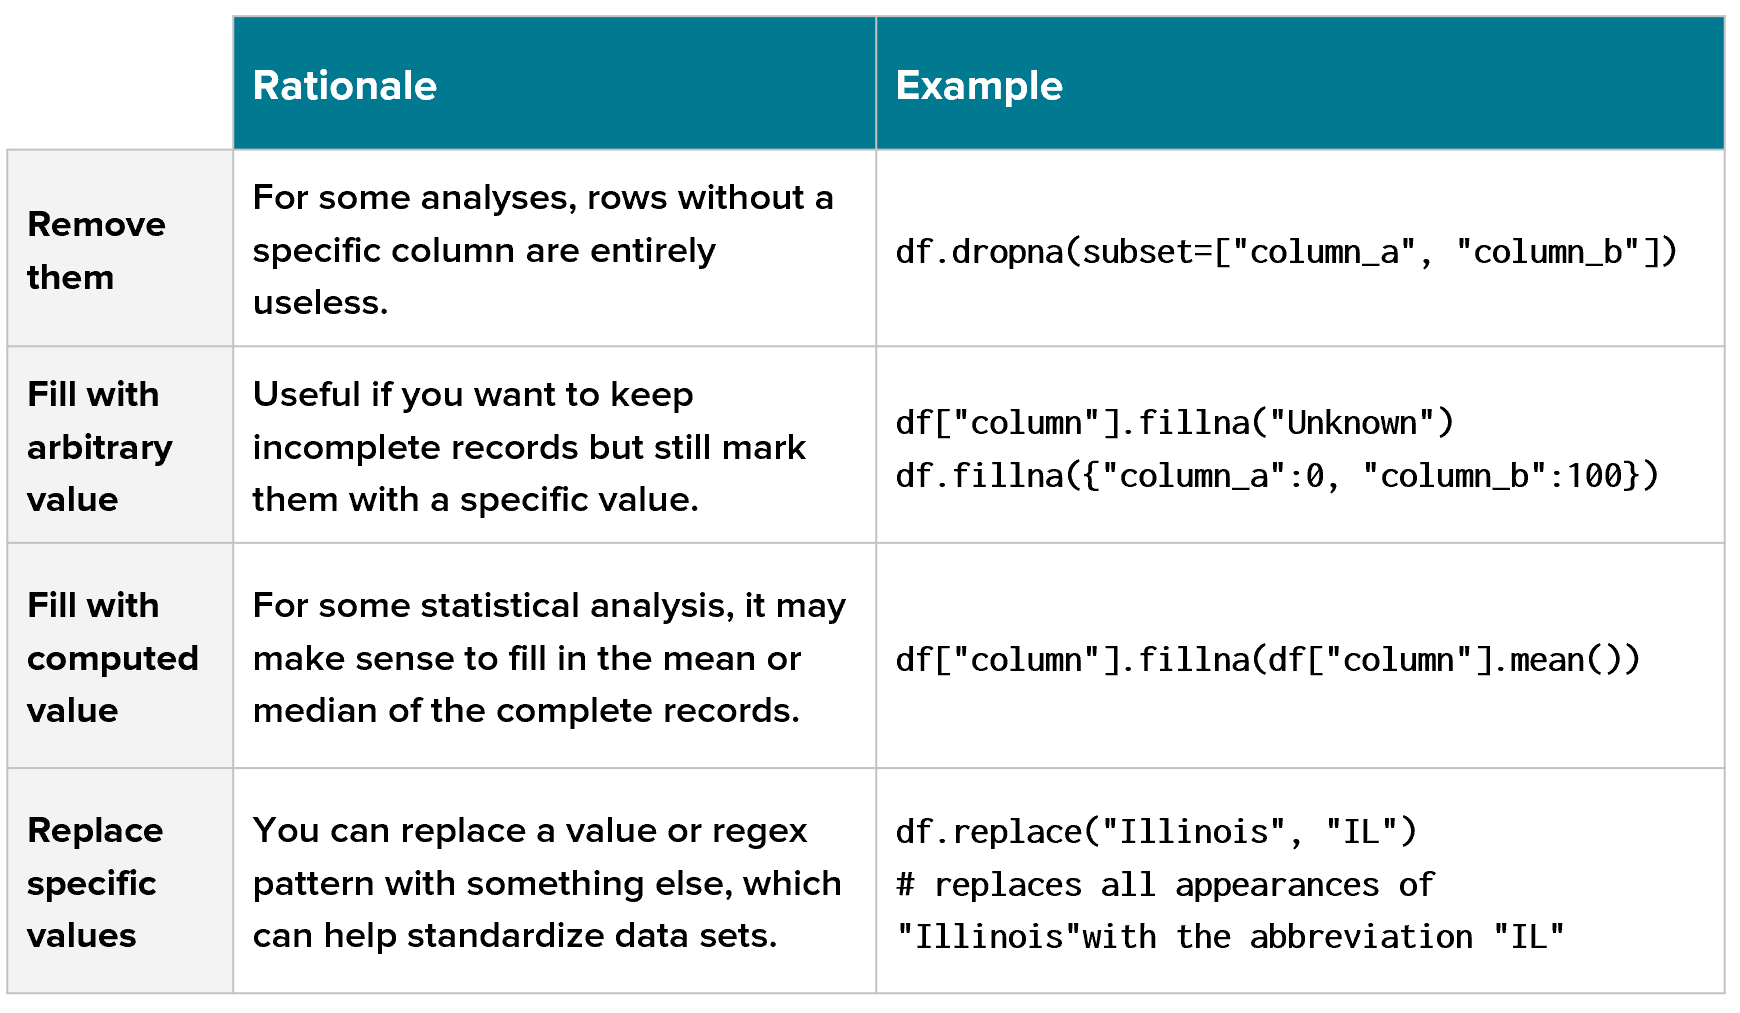
</div>


### Identifying & Filling Missing Data

We can use the `.isnull()` and `.sum()` functions to count the nulls in each column. Chain on the `.sort_values()` function to find the columns with the largest number of nulls.


In [17]:
# show how many nulls in each column, sort them descending
coffee.isnull().sum().sort_values(ascending = False)


customer_since             25042
customer_generation        25042
customer_id                25033
transaction_date               0
transaction_time               0
quantity                       0
line_item_amount               0
unit_price                     0
product_group                  0
product_category               0
product_type                   0
current_wholesale_price        0
customer_birth_year            0
dtype: int64

In [18]:
# show the percentage of nulls in each column
coffee.isnull().mean().sort_values(ascending = False)




customer_since             0.501904
customer_generation        0.501904
customer_id                0.501724
transaction_date           0.000000
transaction_time           0.000000
quantity                   0.000000
line_item_amount           0.000000
unit_price                 0.000000
product_group              0.000000
product_category           0.000000
product_type               0.000000
current_wholesale_price    0.000000
customer_birth_year        0.000000
dtype: float64

- you can also see how many nulls in each row instead of each column by specifying the axis

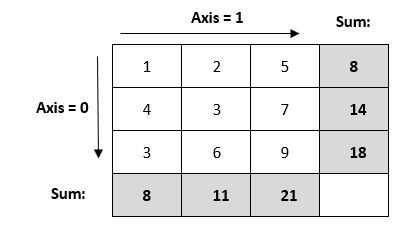

In [20]:
# you can also see how many nulls in each row instead of each column
# using sum(axis= 1)

coffee.isnull().sum(axis=1).sort_values(ascending = False)


32942    3
17428    3
17438    3
17437    3
17436    3
        ..
21727    0
21723    0
21722    0
21714    0
49893    0
Length: 49894, dtype: int64

### Visualizing Missing Data

Visualization can help identify patterns in missingness. The [`missingno`](https://github.com/ResidentMario/missingno) library is particularly useful for this purpose.

#### Using `Seaborn` library to Vistualize missing data


<Axes: >

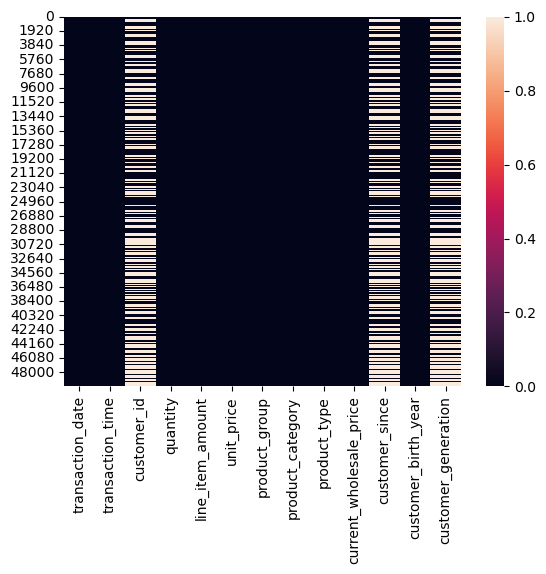

In [22]:
# using seaborn heatmap to display the missing in color 
import seaborn as sns

sns.heatmap(coffee.isnull())

#### Using `missingno` library to Vistualize missing data


<Axes: >

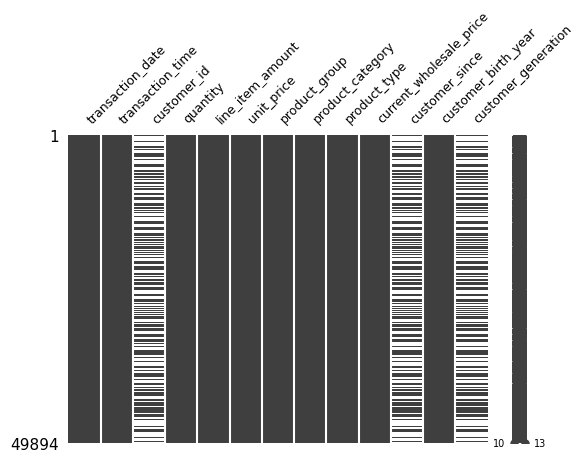

In [23]:
# For visualization of missing data
import missingno as msno

# Create a matrix visualization of missing values

msno.matrix(coffee, figsize=(6,4), fontsize = 9)

<Axes: >

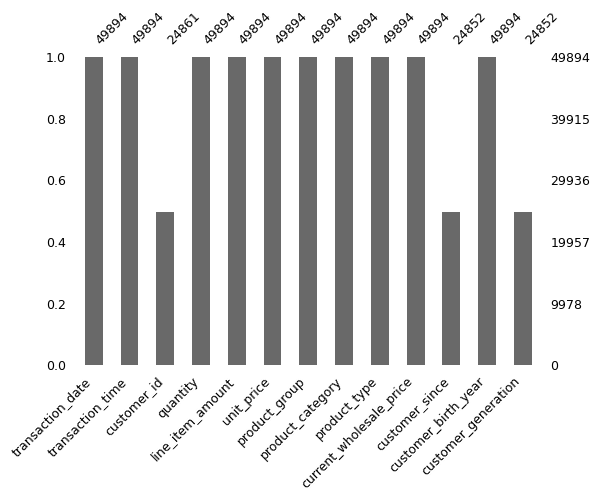

In [25]:
# Create a bar chart showing the count of missing values by column

msno.bar(coffee,figsize = (6,4), fontsize = 9)

>  The missingno correlation heatmap measures nullity correlation: how strongly the presence or absence of one variable affects the presence of another

<Axes: >

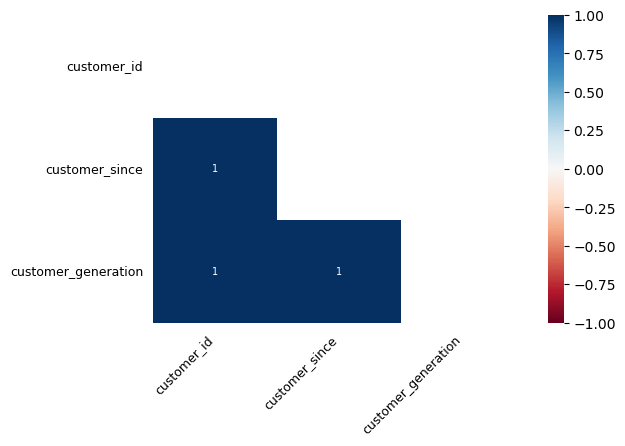

In [27]:
# Create a heatmap to show correlations between missingness

msno.heatmap(coffee,figsize = (6,4), fontsize = 9)

#### Filling missing data in `customer_id` column




In [28]:
# what is the data type of column 'customer_id'

coffee["customer_id"].dtype

dtype('float64')

In [29]:
# Check the tail of coffee dataframe

coffee.tail()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation
49889,2019-04-24,9:31:54,8113.0,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-01-08,1998.0,Gen Z
49890,2019-04-25,6:17:12,5778.0,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-04-08,1956.0,Baby Boomers
49891,2019-04-25,10:48:21,NaN,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,NaT,1959.0,NaN
49892,2019-04-25,8:54:27,8039.0,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-26,1963.0,Baby Boomers
49893,2019-04-25,14:32:27,8081.0,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-29,1980.0,Older Millennials


##### Modify `customer_id` from `float` to `string`


- Important Notice:
    - Convert a column from float to string, using:
     ```python
    coffee['customer_id']= coffee['customer_id'].astype(str) 
    ```
    - If that column contains Null values `NaN` then it will remains as Null values 
    - It is better to unify all the missing values that you can't impute in every column to something common, let's say `missing` or `unknown`
    - Apply the following to replace NaN null values to `unknown`
    ```python
        coffee['customer_id']= coffee['customer_id'].fillna('unknown')
    ```


In [30]:
# Convert customer_id to string
coffee['customer_id']= coffee['customer_id'].astype(str) 
# show the tail of the coffee dataframe
coffee.tail()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation
49889,2019-04-24,9:31:54,8113.0,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-01-08,1998.0,Gen Z
49890,2019-04-25,6:17:12,5778.0,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-04-08,1956.0,Baby Boomers
49891,2019-04-25,10:48:21,nan,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,NaT,1959.0,NaN
49892,2019-04-25,8:54:27,8039.0,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-26,1963.0,Baby Boomers
49893,2019-04-25,14:32:27,8081.0,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-29,1980.0,Older Millennials


In [32]:
# replace the string 'nan' to 'unknown'
coffee['customer_id'] = coffee['customer_id'].fillna('unknown')
# show the tail of the coffee dataframe
coffee.tail()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation
49889,2019-04-24,9:31:54,8113.0,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-01-08,1998.0,Gen Z
49890,2019-04-25,6:17:12,5778.0,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-04-08,1956.0,Baby Boomers
49891,2019-04-25,10:48:21,nan,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,NaT,1959.0,NaN
49892,2019-04-25,8:54:27,8039.0,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-26,1963.0,Baby Boomers
49893,2019-04-25,14:32:27,8081.0,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-29,1980.0,Older Millennials


In [33]:
# remove the '.0' from the customer id using .str.replace
coffee["customer_id"] = coffee["customer_id"].str.replace('.0','')
# show the tail of the coffee dataframe
coffee.tail()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation
49889,2019-04-24,9:31:54,8113,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-01-08,1998.0,Gen Z
49890,2019-04-25,6:17:12,5778,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-04-08,1956.0,Baby Boomers
49891,2019-04-25,10:48:21,nan,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,NaT,1959.0,NaN
49892,2019-04-25,8:54:27,8039,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-26,1963.0,Baby Boomers
49893,2019-04-25,14:32:27,8081,1,8.95,$8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-29,1980.0,Older Millennials


In [34]:
# let's check the type of customer_id if changed to string
coffee.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49894 entries, 0 to 49893
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_date         49894 non-null  datetime64[ns]
 1   transaction_time         49894 non-null  object        
 2   customer_id              49894 non-null  object        
 3   quantity                 49894 non-null  int64         
 4   line_item_amount         49894 non-null  float64       
 5   unit_price               49894 non-null  object        
 6   product_group            49894 non-null  object        
 7   product_category         49894 non-null  object        
 8   product_type             49894 non-null  object        
 9   current_wholesale_price  49894 non-null  float64       
 10  customer_since           24852 non-null  datetime64[ns]
 11  customer_birth_year      49894 non-null  float64       
 12  customer_generation      24852 n

In [35]:
# check the 'customer_id' if there is no null anymore
coffee.isnull().sum()


transaction_date               0
transaction_time               0
customer_id                    0
quantity                       0
line_item_amount               0
unit_price                     0
product_group                  0
product_category               0
product_type                   0
current_wholesale_price        0
customer_since             25042
customer_birth_year            0
customer_generation        25042
dtype: int64

### Using `apply()` to modify the data

- In pandas, the apply() function is used to apply a function along an axis of a DataFrame or Series. It allows you to perform custom operations on the data in a flexible manner. The apply() function can be used with both DataFrame and Series objects.
- The apply() function takes each element or row/column of the DataFrame or Series, passes it to the specified function, and returns the result

In [17]:
# show the data type of the unit_price using .dtypes
# you can see it is object or string




In [36]:
# show the head of 'unit_price'
coffee["unit_price"].head()

0     $2.50 
1     $2.50 
2     $2.50 
3     $2.50 
4     $2.50 
Name: unit_price, dtype: object

- We need to convert it to a numeric but first we need to remove the dollar sign `$` to be able to convert


> Let's create a function to remove the dollar sign `$` from the column `unit_price`

In [37]:
# create a function to remove the dollar sign `$` from the column `unit_price`
def strip_dollar_sign(x):
    return x.replace("$","")



#### Using `apply()` to modify the data along a `Series`

Now we can apply this function directly to every row in our orders DataFrame at once using a good pandas function called `.apply()`.

This will pass each row as an individual piece of input into our newly created function and append the output of our function to a new column.

This output will be whatever our function **returns**, so be careful not to use a print statement instead. The default output of a function that is missing a return statement will be a NoneType object, which will often appear as just the word "None".

In [41]:
# apply the function to the unit_price to remove the dollar sign
coffee["unit_price"]=coffee["unit_price"].apply(strip_dollar_sign).astype(float)

# Alternativaly you can use .str.replace('$','')

# show the head of coffee dataset
coffee.head(3)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation
0,2019-04-01,12:04:43,558,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials
1,2019-04-01,11:15:38,22,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers
2,2019-04-01,12:05:31,659,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z


We can see above that the data type of the unit_price is still an object
We need to convert it to a number using either one of the following:
- `df.astype(float)` 
- `df.astype(int)`  
- `pd.to_numeric`

Note: save the converted values back into the unit_price column

In [21]:
# using .astype(float) to convert 'unit_price' to a float

coffee
# or
# coffee['unit_price'] = pd.to_numeric(coffee['unit_price'])

# or as one step:
# coffee['unit_price'] = coffee['unit_price'].apply(strip_dollar_sign).astype(float)

In [43]:
# check the data type of the column `unit_price` using either .info() or .dtypes
coffee.dtypes

transaction_date           datetime64[ns]
transaction_time                   object
customer_id                        object
quantity                            int64
line_item_amount                  float64
unit_price                        float64
product_group                      object
product_category                   object
product_type                       object
current_wholesale_price           float64
customer_since             datetime64[ns]
customer_birth_year               float64
customer_generation                object
dtype: object

#### Using `apply()` to modify the data along a `Dataframe`


- Let's create a function to add 10% VAT to the value passed to it and return the result

In [44]:
# create a function to add 10% VAT to the value passed to it and return the result
def calc_vat(row):
    return row["unit_price"]*row["quantity"] *0.10
    # write code here


Using `.apply()`, create a new column called `vat` by applying the `vat` function created earlier to the `unit_price` multiplied by `quantity` and `10%`
- Notice that `axis=1` to indicate that it is a complete row passed to a function with multiple columns.

In [45]:
# create a new column called `vat` by applying the `calc_vat` function
coffee["vat"] = coffee.apply(calc_vat,axis =1)
# show the head of coffee dataset
coffee.head(3)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,vat
0,2019-04-01,12:04:43,558,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.25
1,2019-04-01,11:15:38,22,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.25
2,2019-04-01,12:05:31,659,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,0.50


In [46]:
# alternativaly, you can multiply 0.10 to the columns

coffee["vat"] = coffee["unit_price"] * coffee["quantity"] *0.1

#### Filling missing data in `customer_generation` column using `apply()`

- We can fill the customer_generation based on the following birth years:
  - Baby Boomers: 1950-1964
  - Gen X: 1965-1979
  - Older Millennials: 1980-1989
  - Younger Millennials:1990-1994
  - Gen Z: 1995-2001

In [49]:
# 1. Define the function to evaluate each row
def fill_generation(row):
    # If customer_generation already has a value (is not null), do nothing
    # To safely test if an individual cell is empty use pd.isna()
    if pd.notna(row["customer_generation"]):
        return row["customer_generation"]
    
    
    # Grab the birth year
    year = row["customer_birth_year"]
    
    # Return birth year ranges
    if (1950 <=year) and (year <=1964):
        return "Baby Boomers"
    elif (year >= 1965) and (year <= 1979):
        return "Gen X"
    elif (year >= 1980) and (year <= 1989):
        return "Older Millennials" 
    elif (year >= 1990) and (year <= 1994):
        return "Younger Millennials"
    elif (year >= 1995) and (year <= 2001):
        return "Gen Z"    
    



In [55]:
# Apply the function across the columns (axis=1 means row-by-row)
coffee["customer_generation"]=coffee.apply(fill_generation,axis =1)

In [56]:
# check the 'customer_generation' if there is no null anymore
coffee.isnull().sum()

transaction_date               0
transaction_time               0
customer_id                    0
quantity                       0
line_item_amount               0
unit_price                     0
product_group                  0
product_category               0
product_type                   0
current_wholesale_price        0
customer_since             25042
customer_birth_year            0
customer_generation            0
vat                            0
dtype: int64

### Adding calculated values to our dataset
---

Many of our cleaning operations involve applying an operation to a Series. This can be used to create new columns based on existing data.

For this example, let's create a column `total` that is the multiplication of `quantity` and `unit_price`


In [59]:
#Add a new column for total price
coffee["total"] = (coffee["quantity"] * coffee["unit_price"]) + coffee["vat"]

# show the head of coffee dataset
coffee.head(2)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,vat,total
0,2019-04-01,12:04:43,558,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.25,2.75
1,2019-04-01,11:15:38,22,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.25,2.75


In [60]:
# create a new column called 'day' to show the day name of transaction
# use dt.day_name() to extract the day name
coffee["day"] = coffee["transaction_date"].dt.day_name()

# display the head
coffee.head(2)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,vat,total,day
0,2019-04-01,12:04:43,558,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.25,2.75,Monday
1,2019-04-01,11:15:38,22,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.25,2.75,Monday


In [61]:
# create a new column called 'area' with the string "Manama".
coffee["area"] = "Manama"

# display the head
coffee.head(3)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,vat,total,day,area
0,2019-04-01,12:04:43,558,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.25,2.75,Monday,Manama
1,2019-04-01,11:15:38,22,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.25,2.75,Monday,Manama
2,2019-04-01,12:05:31,659,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,0.50,5.50,Monday,Manama


In [62]:
# Add a new column concatenating two columns
coffee["test"] = coffee["area"] + ' ' +coffee["customer_generation"]

# display the head
coffee.head(3)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,vat,total,day,area,test
0,2019-04-01,12:04:43,558,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.25,2.75,Monday,Manama,Manama Older Millennials
1,2019-04-01,11:15:38,22,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.25,2.75,Monday,Manama,Manama Baby Boomers
2,2019-04-01,12:05:31,659,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,0.50,5.50,Monday,Manama,Manama Gen Z


### Drop columns

In [65]:
# drop the column 'test' that was created earlier

coffee.drop(columns = "test")




,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,vat,total,day,area
0,2019-04-01,12:04:43,558,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.250,2.750,Monday,Manama
1,2019-04-01,11:15:38,22,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.250,2.750,Monday,Manama
2,2019-04-01,12:05:31,659,2,5.00,2.50,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,0.500,5.500,Monday,Manama
3,2019-04-01,16:49:38,407,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.250,2.750,Monday,Manama
4,2019-04-01,19:17:34,537,2,5.00,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,0.500,5.500,Monday,Manama
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49889,2019-04-24,9:31:54,8113,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-01-08,1998.0,Gen Z,0.895,9.845,Wednesday,Manama
49890,2019-04-25,6:17:12,5778,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-04-08,1956.0,Baby Boomers,0.895,9.845,Thursday,Manama
49891,2019-04-25,10:48:21,nan,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,NaT,1959.0,Baby Boomers,0.895,9.845,Thursday,Manama
49892,2019-04-25,8:54:27,8039,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-26,1963.0,Baby Boomers,0.895,9.845,Thursday,Manama


In [66]:
# display the head
coffee.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,vat,total,day,area,test
0,2019-04-01,12:04:43,558,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.25,2.75,Monday,Manama,Manama Older Millennials
1,2019-04-01,11:15:38,22,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.25,2.75,Monday,Manama,Manama Baby Boomers
2,2019-04-01,12:05:31,659,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,0.50,5.50,Monday,Manama,Manama Gen Z
3,2019-04-01,16:49:38,407,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.25,2.75,Monday,Manama,Manama Baby Boomers
4,2019-04-01,19:17:34,537,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,0.50,5.50,Monday,Manama,Manama Older Millennials


In [67]:
# Drop Multiple columns
# drop 'test' and 'area' columns

coffee.drop(columns = ["test","area"])

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,vat,total,day
0,2019-04-01,12:04:43,558,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.250,2.750,Monday
1,2019-04-01,11:15:38,22,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.250,2.750,Monday
2,2019-04-01,12:05:31,659,2,5.00,2.50,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,0.500,5.500,Monday
3,2019-04-01,16:49:38,407,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.250,2.750,Monday
4,2019-04-01,19:17:34,537,2,5.00,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,0.500,5.500,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49889,2019-04-24,9:31:54,8113,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-01-08,1998.0,Gen Z,0.895,9.845,Wednesday
49890,2019-04-25,6:17:12,5778,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-04-08,1956.0,Baby Boomers,0.895,9.845,Thursday
49891,2019-04-25,10:48:21,nan,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,NaT,1959.0,Baby Boomers,0.895,9.845,Thursday
49892,2019-04-25,8:54:27,8039,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-26,1963.0,Baby Boomers,0.895,9.845,Thursday


In [69]:
# display the head
coffee.head()

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,vat,total,day,area,test
0,2019-04-01,12:04:43,558,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.25,2.75,Monday,Manama,Manama Older Millennials
1,2019-04-01,11:15:38,22,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.25,2.75,Monday,Manama,Manama Baby Boomers
2,2019-04-01,12:05:31,659,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,0.50,5.50,Monday,Manama,Manama Gen Z
3,2019-04-01,16:49:38,407,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.25,2.75,Monday,Manama,Manama Baby Boomers
4,2019-04-01,19:17:34,537,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,0.50,5.50,Monday,Manama,Manama Older Millennials


In [71]:
# create a new dataframe which is the same as coffee but without a specific
# column. We need to drop the column while we assign the new dataframe
coffee_cleaned = coffee.drop(columns = ["test","area"])


# show the head of coffee_cleaned dataframe
coffee_cleaned.head(2)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,vat,total,day
0,2019-04-01,12:04:43,558,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.25,2.75,Monday
1,2019-04-01,11:15:38,22,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.25,2.75,Monday


### Addressing Duplicates
---

Fortunately, the issue of duplicate data is a mere pandas method away from being solved! 
1. To show how many rows are duplicated:
```python
df.duplicated().sum()
```
2. To show the duplicated rows:
```python
df[df.duplicated()]
```
3. To drop the duplicated rows:
```python
df.drop_duplicates()
```
4. If we want to drop duplicates based on certain columns, we can do that, too: 
```python
df.drop_duplicates(subset=['column_a', 'column_b'])
```

In [72]:
# Show total number of rows that are duplicated
# To find duplicates on specific column(s), 
# use (subset=[col1,col2])

coffee_cleaned.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
49889    False
49890    False
49891    False
49892    False
49893    False
Length: 49894, dtype: bool

In [77]:
# Display all the rows that are duplicated. 
# Note: The first row occurance is not included

coffee_cleaned[coffee_cleaned.duplicated()]

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,vat,total,day


In [78]:
# drop duplicated from the dataframe coffee_cleaned. 
# Make sure you save the changes to the same dataframe
coffee_cleaned = coffee_cleaned.drop_duplicates()


### Save your Cleaned DataFrame
---

In [79]:
# save the cleaned dataframe to a new csv file, without saving the index along with it

coffee_cleaned.to_csv("coffee_shop_cleaned.csv")

## Lesson Summary
---
Today, we:

- Used pandas to handle missing or problematic data values.
- Identified appropriate cleaning strategies for specific types of data.



In [47]:
%autosave 0

Autosave disabled
